In [25]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import matplotlib.pyplot as plt

# Dataset

In [ ]:
df_base = pd.read_csv("Data/struct/features_main_struct.csv")
df = df_base

In [27]:
print(df.shape)
print(df.dtypes)
print(df['split'].value_counts())
print(df['label'].value_counts())
print(df.isna().sum()[df.isna().sum() > 0])   # flag any missing values
df.head()

(13489, 33)
uid                              str
split                            str
label                          int64
source                           str
attack_type                      str
obf_invisible                  int64
obf_homoglyphs                 int64
obf_fullwidth                float64
obf_accents                  float64
obf_base64                     int64
evasion_gap                    int64
non_ascii_ratio              float64
lex_override                   int64
lex_override_verb_only         int64
lex_exfil                      int64
lex_roleplay                   int64
lex_prefix_refusal             int64
lex_coercion                   int64
lex_harmful                    int64
delimiters                     int64
imperative_ratio             float64
second_person_ratio          float64
is_question                    int64
char_entropy                 float64
log_chars                    float64
upper_ratio                  float64
punct_ratio               

,uid,split,label,source,attack_type,obf_invisible,obf_homoglyphs,obf_fullwidth,obf_accents,obf_base64,...,char_entropy,log_chars,upper_ratio,punct_ratio,struct_n_sentences,struct_avg_sentence_len,struct_compulsion_density,struct_list_items,struct_list_density,struct_caps_word_ratio
0,safeguard:test:10,train,1,safeguard,instruction_override,0,0,0.0,0.000000,0,...,3.928772,4.442651,0.013889,0.011905,1,12.0,0.000000,0,0.0,0.000000
1,safeguard:test:100,train,0,safeguard,none,0,0,0.0,0.000000,0,...,4.456455,6.558198,0.041769,0.176136,7,20.0,0.857143,0,0.0,0.057143
2,safeguard:test:1001,train,0,safeguard,none,0,0,0.0,0.005249,0,...,4.473714,5.945421,0.060201,0.039370,5,12.2,0.000000,0,0.0,0.000000
3,safeguard:test:1003,train,0,safeguard,none,0,0,0.0,0.000000,0,...,4.193096,4.304065,0.018519,0.095890,2,6.0,0.000000,0,0.0,0.000000
4,safeguard:test:1005,train,0,safeguard,none,0,0,0.0,0.000000,0,...,3.719852,3.465736,0.041667,0.032258,1,7.0,0.000000,0,0.0,0.000000


In [28]:
# using train split and sorting by attack (1)
df_cluster = df[(df['split'] == 'train') & (df['label'] == 1)].copy()

In [29]:
meta_cols = ['uid', 'split', 'source', 'attack_type', 'label']
feature_cols = [c for c in df.columns if c not in meta_cols]

X = df_cluster[feature_cols]        # this is what DBSCAN sees
meta = df_cluster[meta_cols]        # kept alongside, same row order, same index

In [30]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

### Feature Redundancy Check / Dimension Reduction
The 28 engineered features are highly correlated/redundant (many lexical
flags rarely co-occur, several structural features overlap). Before
clustering, PCA is used to find how many combined components are needed
to retain most of the real variance, so DBSCAN operates on fewer, more
meaningful dimensions rather than the full sparse 28-feature space.

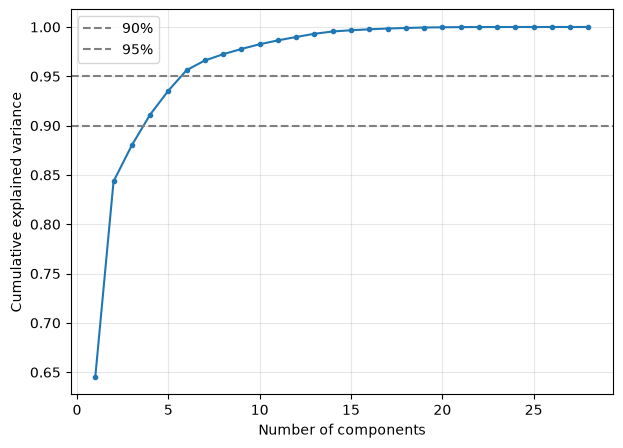

Components needed for 90%: 4
Components needed for 95%: 6


In [31]:
from sklearn.decomposition import PCA

pca_full = PCA().fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=3)
plt.axhline(0.90, color='gray', ls='--', label='90%')
plt.axhline(0.95, color='gray', ls='--', label='95%')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1
print(f"Components needed for 90%: {n_90}")
print(f"Components needed for 95%: {n_95}")

In [32]:
n_components = n_95  # = 6

pca_reduced = PCA(n_components=n_components)
X_reduced = pca_reduced.fit_transform(X_scaled)

print(X_reduced.shape)  # should print (3634, 6)

(3582, 6)


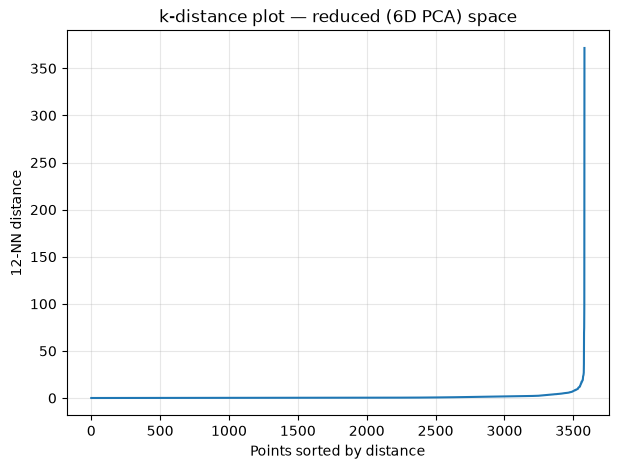

50th percentile: 0.248
75th percentile: 0.997
90th percentile: 2.307
95th percentile: 4.476
97th percentile: 6.102
98th percentile: 8.032
99th percentile: 12.153
99.5th percentile: 17.629
100th percentile: 371.609


In [33]:
min_samples = 2 * n_components  # = 12
k = min_samples

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_reduced)
distances, indices = neighbors_fit.kneighbors(X_reduced)

k_dist = np.sort(distances[:, k-1])

plt.figure(figsize=(7, 5))
plt.plot(k_dist)
plt.ylabel(f"{k}-NN distance")
plt.xlabel("Points sorted by distance")
plt.title("k-distance plot — reduced (6D PCA) space")
plt.grid(alpha=0.3)
plt.show()

for p in [50, 75, 90, 95, 97, 98, 99, 99.5, 100]:
    print(f"{p}th percentile: {np.percentile(k_dist, p):.3f}")

### eps selecting

In [34]:
for eps_test in [3.0, 4.0, 5.0]:
    db_test = DBSCAN(eps=eps_test, min_samples=min_samples)
    labels_test = db_test.fit_predict(X_reduced)
    mask_test = labels_test != -1
    sil = silhouette_score(X_reduced[mask_test], labels_test[mask_test])
    dbi = davies_bouldin_score(X_reduced[mask_test], labels_test[mask_test])
    n_clust = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    print(f"eps={eps_test}: clusters={n_clust}, silhouette={sil:.3f}, davies-bouldin={dbi:.3f}")

eps=3.0: clusters=3, silhouette=0.869, davies-bouldin=0.412
eps=4.0: clusters=2, silhouette=0.863, davies-bouldin=0.237
eps=5.0: clusters=2, silhouette=0.846, davies-bouldin=0.254


# Running DBSCAN

In [35]:
eps = 4.0

db = DBSCAN(eps=eps, min_samples=min_samples)
cluster_labels = db.fit_predict(X_reduced)

meta = meta.copy()
meta['cluster_id'] = cluster_labels

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = (cluster_labels == -1).sum()
print(f"Clusters found: {n_clusters}")
print(f"Noise points: {n_noise} ({n_noise/len(cluster_labels):.1%})")
print(pd.Series(cluster_labels).value_counts().sort_index())

Clusters found: 2
Noise points: 150 (4.2%)
-1     150
 0    3385
 1      47
Name: count, dtype: int64


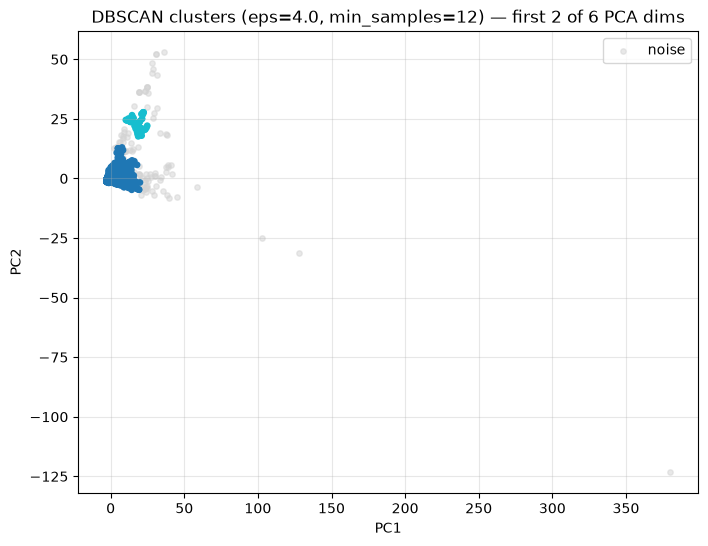

In [36]:
plt.figure(figsize=(8, 6))

noise_mask = cluster_labels == -1

# outliers
plt.scatter(X_reduced[noise_mask, 0], X_reduced[noise_mask, 1],
            c='lightgray', s=15, label='noise', alpha=0.5)

# actual clusters
plt.scatter(X_reduced[~noise_mask, 0], X_reduced[~noise_mask, 1],
            c=cluster_labels[~noise_mask], cmap='tab10', s=15)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"DBSCAN clusters (eps={eps}, min_samples={min_samples}) — first 2 of {n_components} PCA dims")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [37]:
# Merge cluster assignment onto the original (real, interpretable) features
df_desc = df_cluster[feature_cols].copy()
df_desc['cluster_id'] = meta['cluster_id'].values
df_desc['uid'] = meta['uid'].values
df_desc['attack_type'] = meta['attack_type'].values

# Overall average across all label=1 train rows (the baseline to compare against)
overall_mean = df_cluster[feature_cols].mean()

# Per-cluster averages
cluster_means = df_desc.groupby('cluster_id')[feature_cols].mean()

# How far each cluster's average is from the overall average
diff_from_overall = cluster_means.subtract(overall_mean, axis=1)

print(diff_from_overall.T)  # transposed so features are rows, clusters are columns — easier to scan

cluster_id                        -1         0          1
obf_invisible               0.043317 -0.001873  -0.003350
obf_homoglyphs              0.057487 -0.002513  -0.002513
obf_fullwidth               0.028119 -0.001193  -0.003823
obf_accents                -0.000215  0.000013  -0.000259
obf_base64                  0.006387 -0.000279  -0.000279
evasion_gap                 0.075254 -0.003269  -0.004746
non_ascii_ratio             0.000421 -0.000036   0.001218
lex_override                0.022580 -0.008115   0.512367
lex_override_verb_only      0.341485 -0.023114   0.574819
lex_exfil                  -0.314696  0.020518  -0.473419
lex_roleplay               11.123417 -0.867592  26.984836
lex_prefix_refusal          0.478537 -0.026662   0.393005
lex_coercion                0.135433 -0.004232  -0.127404
lex_harmful                 1.296494 -0.057135  -0.022797
delimiters                  1.451502 -0.063092  -0.088498
imperative_ratio           -0.366111  0.021837  -0.404281
second_person_

In [38]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(df_desc['attack_type'], df_desc['cluster_id'])
nmi = normalized_mutual_info_score(df_desc['attack_type'], df_desc['cluster_id'])
print(f"ARI: {ari:.3f}")
print(f"NMI: {nmi:.3f}")

ARI: 0.013
NMI: 0.061


In [39]:
mask = df_desc['cluster_id'] != -1
ari_clean = adjusted_rand_score(df_desc['attack_type'][mask], df_desc['cluster_id'][mask])
nmi_clean = normalized_mutual_info_score(df_desc['attack_type'][mask], df_desc['cluster_id'][mask])
print(f"ARI (excl. noise): {ari_clean:.3f}")
print(f"NMI (excl. noise): {nmi_clean:.3f}")

ARI (excl. noise): 0.003
NMI (excl. noise): 0.028


### Outliers labels

In [40]:
print(df_desc[df_desc['cluster_id'] == -1]['attack_type'].value_counts())

attack_type
roleplay_jailbreak             105
harmful_content_request         10
other_injection                  9
fake_completion_delimiter        8
instruction_override             8
prefix_refusal_suppression       5
prompt_leak_exfiltration         4
social_engineering_coercion      1
Name: count, dtype: int64


### Label composition per cluster

In [41]:
composition = pd.crosstab(df_desc['cluster_id'], df_desc['attack_type'], normalize='index') * 100
sizes = df_desc['cluster_id'].value_counts().sort_index()
print(composition.round(1))
print(sizes)

attack_type  fake_completion_delimiter  harmful_content_request  \
cluster_id                                                        
-1                                 5.3                      6.7   
 0                                 1.2                      2.4   
 1                                 0.0                      0.0   

attack_type  instruction_override  other_injection  \
cluster_id                                           
-1                            5.3              6.0   
 0                           24.0             17.9   
 1                            0.0              0.0   

attack_type  prefix_refusal_suppression  prompt_leak_exfiltration  \
cluster_id                                                          
-1                                  3.3                       2.7   
 0                                  7.9                      28.5   
 1                                  0.0                       0.0   

attack_type  roleplay_jailbreak  social_enginee

### Top differentiating features per cluster

In [42]:
for cid in diff_from_overall.index:
    top = diff_from_overall.loc[cid].abs().sort_values(ascending=False).head(3)
    print(f"\nCluster {cid} top differentiators:")
    print(diff_from_overall.loc[cid][top.index])


Cluster -1 top differentiators:
struct_n_sentences         52.154551
lex_roleplay               11.123417
struct_avg_sentence_len     9.920633
Name: -1, dtype: float64

Cluster 0 top differentiators:
struct_n_sentences        -2.794145
lex_roleplay              -0.867592
struct_avg_sentence_len   -0.492942
Name: 0, dtype: float64

Cluster 1 top differentiators:
struct_n_sentences         34.787175
lex_roleplay               26.984836
struct_avg_sentence_len     3.840708
Name: 1, dtype: float64


### Examples per cluster

In [43]:
df_text = pd.read_csv("Data/dataset_main.csv")

for cid in sorted(df_desc['cluster_id'].unique()):
    sample_uids = df_desc[df_desc['cluster_id'] == cid]['uid'].sample(
        min(3, (df_desc['cluster_id'] == cid).sum()), random_state=42
    )
    examples = df_text[df_text['uid'].isin(sample_uids)][['uid', 'text']]
    print(f"\n=== Cluster {cid} examples ===")
    print(examples.to_string(index=False))


=== Cluster -1 examples ===
                      uid                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  